**P3: Using Cartopy for Mapping**

In [1]:
#importing packages
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

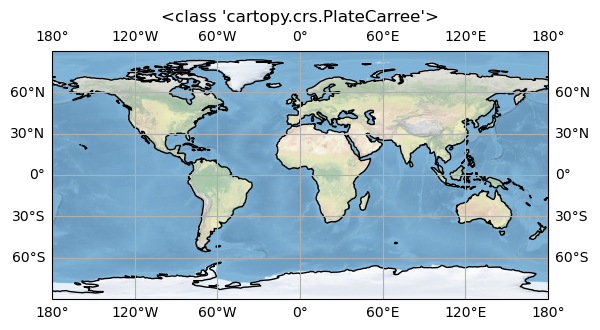

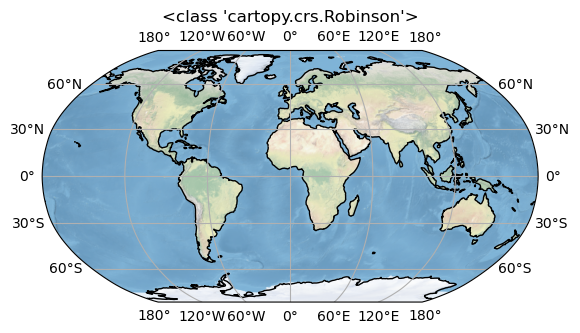

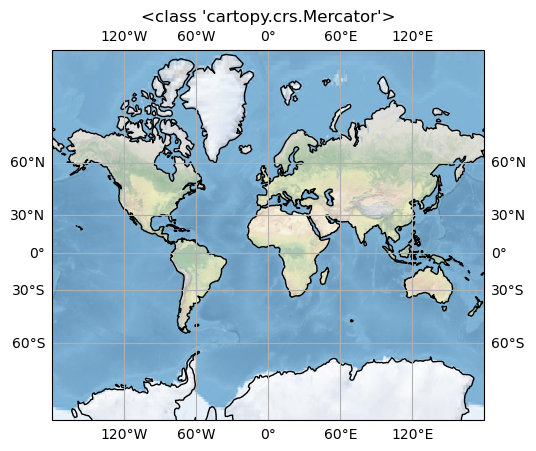

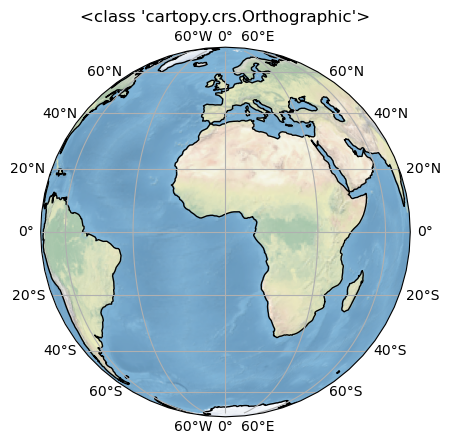

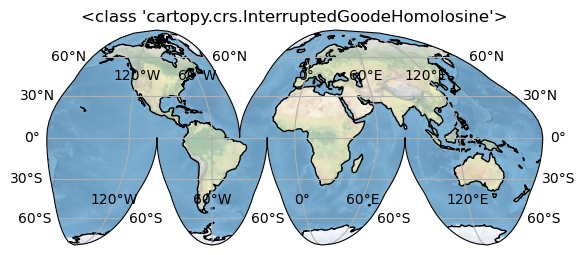

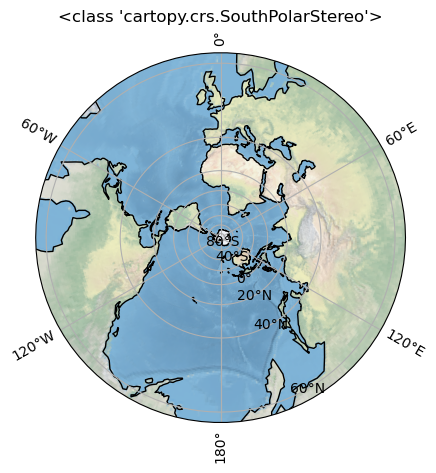

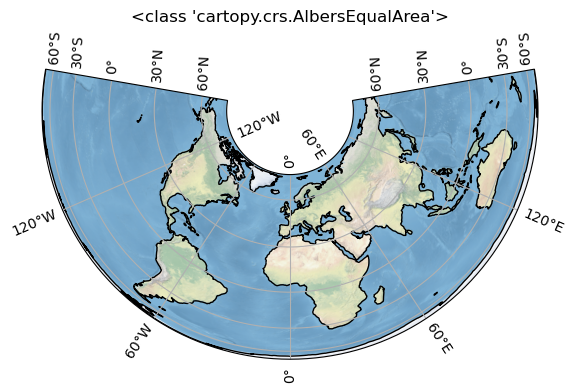

In [2]:
#Projections
projections = [ccrs.PlateCarree(),
               ccrs.Robinson(),
               ccrs.Mercator(),
               ccrs.Orthographic(),
               ccrs.InterruptedGoodeHomolosine(),
               ccrs.SouthPolarStereo(),
               ccrs.AlbersEqualArea()
              ]
for proj in projections:
    plt.figure()
    ax = plt.axes(projection=proj)
    ax.stock_img()
    ax.coastlines()
    ax.gridlines(draw_labels=True)
    ax.set_title(f'{type(proj)}')

**Projections i will be worling with**

In [3]:
ccrs.SouthPolarStereo()

<Projected CRS: +proj=stere +ellps=WGS84 +lat_0=-90 +lon_0=0.0 +x_ ...>
Name: unknown
Axis Info [cartesian]:
- E[north]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unknown
- method: Polar Stereographic (variant A)
Datum: Unknown based on WGS 84 ellipsoid
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [4]:
ccrs.PlateCarree() 

<Projected CRS: +proj=eqc +ellps=WGS84 +a=6378137.0 +lon_0=0.0 +to ...>
Name: unknown
Axis Info [cartesian]:
- E[east]: Easting (unknown)
- N[north]: Northing (unknown)
- h[up]: Ellipsoidal height (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unknown
- method: Equidistant Cylindrical
Datum: Unknown based on WGS 84 ellipsoid
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [5]:
ccrs.Orthographic()

<Projected CRS: +proj=ortho +a=6378137.0 +lon_0=0.0 +lat_0=0.0 +al ...>
Name: unknown
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unknown
- method: Orthographic
Datum: unknown
- Ellipsoid: unknown
- Prime Meridian: Greenwich

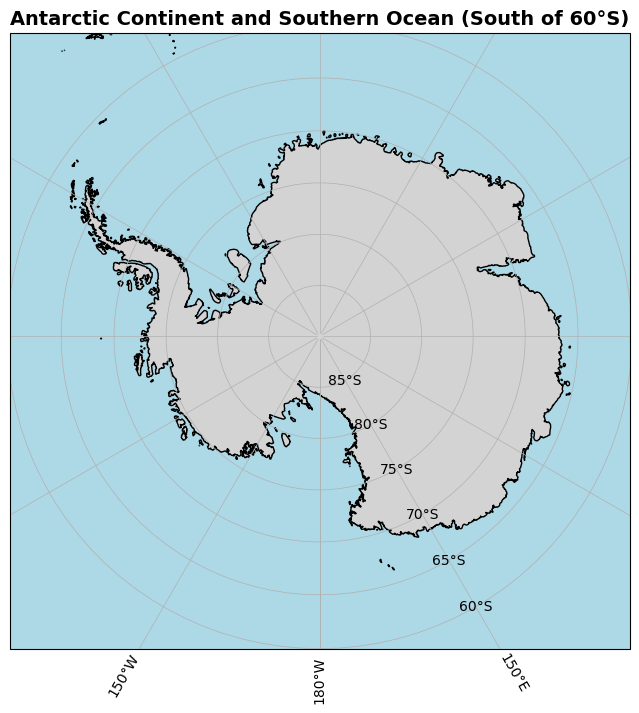

In [6]:
fig = plt.figure(figsize=(8,8))

ax = plt.axes(projection=ccrs.SouthPolarStereo())

ax.set_extent([-180,180,-90,-60], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.coastlines(resolution='10m')

gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='-')

gl.xlocator = plt.FixedLocator(np.arange(-180,181,30))
gl.ylocator = plt.FixedLocator(np.arange(-90,-59,5))

gl.top_labels = False
gl.right_labels = False

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

plt.title(
    "Antarctic Continent and Southern Ocean (South of 60°S)",
    fontsize=14,
    weight='bold'
)

plt.show()

**SouthPoleStereo**

I chose this projection because it is well suited for polar regions, it minimizes distortion near the pole and provides a symmetric view of Antarctica and the Southern Ocean.

The map shows the Antarctica and the southern ocean.

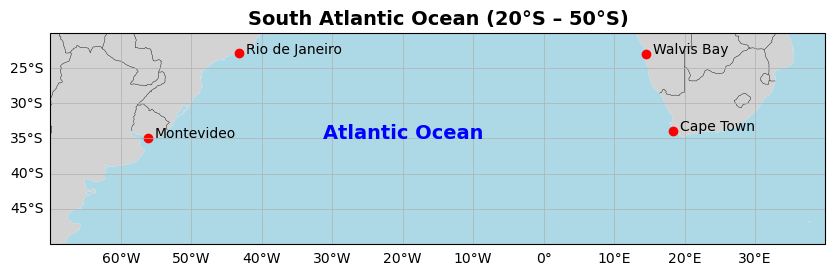

In [7]:
fig = plt.figure(figsize=(10,8))

ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-70,40,-50,-20], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

#Cities
walvis = (14.5058,-22.9575)
cape_town = (18.4241,-33.9249)
rio = (-43.1729,-22.9068)
montevideo = (-56.1645,-34.9011)

ax.plot(*walvis, marker='o', color='red', markersize=6, transform=ccrs.PlateCarree())
ax.plot(*cape_town, marker='o', color='red', markersize=6, transform=ccrs.PlateCarree())
ax.plot(*rio, marker='o', color='red', markersize=6, transform=ccrs.PlateCarree())
ax.plot(*montevideo, marker='o', color='red', markersize=6, transform=ccrs.PlateCarree())

ax.text(walvis[0]+1, walvis[1], "Walvis Bay", transform=ccrs.PlateCarree())
ax.text(cape_town[0]+1, cape_town[1], "Cape Town", transform=ccrs.PlateCarree())
ax.text(rio[0]+1, rio[1], "Rio de Janeiro", transform=ccrs.PlateCarree())
ax.text(montevideo[0]+1, montevideo[1], "Montevideo", transform=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle='-')

gl.top_labels = False
gl.right_labels = False

ax.text(-20, -35, "Atlantic Ocean",
        transform=ccrs.PlateCarree(),
        fontsize=14,
        color='blue',
        weight='bold',
        ha='center')

gl.xlocator = plt.FixedLocator(np.arange(-70,41,10))
gl.ylocator = plt.FixedLocator(np.arange(-50,-19,5))

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

plt.title(
    "South Atlantic Ocean (20°S – 50°S)",
    fontsize=14,
    weight='bold'
)

plt.show()

**PlateCarree**

I chose this projection because it directly maps longitude and latitude coordinates onto the horizontal and vertical axes and the best for plotting specific geographic locations using their longitude and latitude values.

The map shows the South Atlantic region between 20°S and 50°S and four coastal locations which are Walvis Bay, Cape Town, Rio de Janeiro, and Montevideo. 

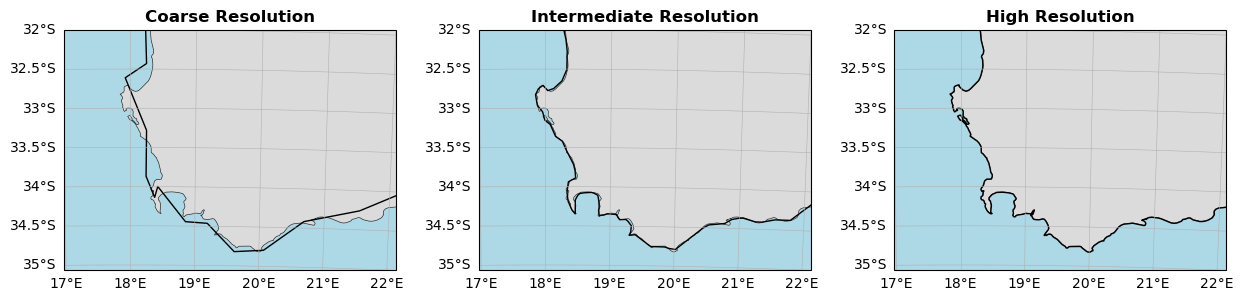

In [8]:
central_lon, central_lat = 18, -34.5
extent = [17, 22, -32, -35]

fig, ax = plt.subplots(
    1,3,
    figsize=(15,6),
    subplot_kw={'projection': ccrs.Orthographic(central_lon, central_lat)}
)

#Coarse Resolution
ax[0].set_extent(extent, crs=ccrs.PlateCarree())

ax[0].coastlines(resolution='110m')

gl0 = ax[0].gridlines(draw_labels=True, linewidth=0.4, linestyle='-')

gl0.top_labels = False
gl0.right_labels = False
gl0.xformatter = LONGITUDE_FORMATTER
gl0.yformatter = LATITUDE_FORMATTER

ax[0].add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', alpha=0.8)
ax[0].add_feature(cfeature.OCEAN, facecolor='lightblue')
ax[0].set_title("Coarse Resolution", weight='bold')

#Intermediate Resolution
ax[1].set_extent(extent, crs=ccrs.PlateCarree())

ax[1].add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', alpha=0.8)
ax[1].add_feature(cfeature.OCEAN, facecolor='lightblue')
ax[1].coastlines(resolution='50m')

gl1 = ax[1].gridlines(draw_labels=True, linewidth=0.4, linestyle='-')

gl1.top_labels = False
gl1.right_labels = False
gl1.left_labels = True

gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER

ax[1].set_title("Intermediate Resolution", weight='bold')

#High Resolution
ax[2].set_extent(extent, crs=ccrs.PlateCarree())

ax[2].add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', alpha=0.8)
ax[2].add_feature(cfeature.OCEAN, facecolor='lightblue')
ax[2].coastlines(resolution='10m')

gl2 = ax[2].gridlines(draw_labels=True, linewidth=0.4, linestyle='-')

gl2.top_labels = False
gl2.right_labels = False
gl2.left_labels = True

gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER

ax[2].set_title("High Resolution", weight='bold')

plt.subplots_adjust(wspace=0.25)

plt.show()

**Orthographic**

I chose this projection to provide a focused regional view. This projection gives a perspective which helps highlight the local geography while maintaining a visually appealing representation of the coastal region.

I mapped three panels to compare coastline with different resolutions, coarse (110m), intermediate (50m), and full (10m). Higher resolution coastline data capture finer geographic details such as small bays, coastal curvature, and minor inlets, while lower resolution datasets represent the coastline with smoother and more generalized shapes. To show this clearly, i overlayed the coastline over the land polygon, and it clearly show how these different resultions fit to the land polygon.